In [1]:
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import os
import glob

from mpl_toolkits.mplot3d import Axes3D
plt.rcParams['text.usetex']=True

import config as cfg
from basic_functions import check_inputpath
from df_makers.data_to_pickle_function import remove_dot_etc

Welcome to JupyROOT 6.28/10


In [2]:
def export_legend(legend, filename="legend.png", expand=[-5,-5,5,5]):
    fig  = legend.figure
    fig.canvas.draw()
    bbox  = legend.get_window_extent()
    bbox = bbox.from_extents(*(bbox.extents + np.array(expand)))
    bbox = bbox.transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(filename, dpi="figure", bbox_inches=bbox)

In [3]:
def evt_disp_maker(bbfile, index):

    expressions = [
        #"MCem_p",
        #"MCem_px",
        #"MCem_py",
        #"MCem_pz",
        #"MCem_orivtx_x",
        #"MCem_orivtx_y",
        #"MCem_orivtx_z",
        
        #"MCep_p",
        #"MCep_px",
        #"MCep_py",
        #"MCep_pz",
        #"MCep_orivtx_x",
        #"MCep_orivtx_y",
        #"MCep_orivtx_z",

        "MCZ_p",
        "MCZ_px",
        "MCZ_py",
        "MCZ_pz",
        #"MCZ_orivtx_x",
        #"MCZ_orivtx_y",
        #"MCZ_orivtx_z",

        "MC_PDG",
        "MC_p",
        "MC_px",
        "MC_py",
        "MC_pz",
        "MC_orivtx_x",
        "MC_orivtx_y",
        "MC_orivtx_z",  
        
        "MC_M1",
        "MC_M2",
        "MC_genStatus",
        "MC_D1",
        
    ]

    expressions += [
        "EVT_Thrust_x",
        "EVT_Thrust_y",
        "EVT_Thrust_z",
        "evt_id",
        "Rec_PV_x",
        "Rec_PV_y",
        "Rec_PV_z",
    ]

    expressions += [
        "Rec_true_PDG",
        "Rec_true_M1",
        "Rec_true_M2",
        "Rec_true_M1ofM1",
        "Rec_true_M2ofM1",
        "Rec_true_p",
        "Rec_true_px",
        "Rec_true_py",
        "Rec_true_pz",
        "Rec_true_orivtx_x",
        "Rec_true_orivtx_y",
        "Rec_true_orivtx_z",
    ]

    data = uproot.concatenate(bbfile+':events', expressions=expressions)[index]

    print(data["evt_id"]) 


    #data = data[data["evt_id"] == evt_id]
    
    # Beam electron and positron
    #emX  = data['MCem_orivtx_x']
    #emY  = data['MCem_orivtx_y']
    #emZ  = data['MCem_orivtx_z']
    #emPX = data['MCem_px']
    #emPY = data['MCem_py']
    #emPZ = data['MCem_pz']

    #epX  = data['MCep_orivtx_x']
    #epY  = data['MCep_orivtx_y']
    #epZ  = data['MCep_orivtx_z']
    #epPX = data['MCep_px']
    #epPY = data['MCep_py']
    #epPZ = data['MCep_pz']

    # Z boson
    #zX = data['MCZ_orivtx_x']
    #zY = data['MCZ_orivtx_y']
    #zZ = data['MCZ_orivtx_z']

    #use reco PV as haven saved true Z position info
    zX = data['Rec_PV_x']
    zY = data['Rec_PV_y']
    zZ = data['Rec_PV_z']

    #thrust components
    thrustX = data['EVT_Thrust_x']
    thrustY = data['EVT_Thrust_y']
    thrustZ = data['EVT_Thrust_z']


    # Final state particles have initial position from orivtx and final from momentum
    feX  = data['Rec_true_orivtx_x'][abs(data['Rec_true_PDG']) == 11].to_numpy()
    feY  = data['Rec_true_orivtx_y'][abs(data['Rec_true_PDG']) == 11].to_numpy()
    feZ  = data['Rec_true_orivtx_z'][abs(data['Rec_true_PDG']) == 11].to_numpy()
    fePX = data['Rec_true_px'][abs(data['Rec_true_PDG']) == 11].to_numpy()
    fePY = data['Rec_true_py'][abs(data['Rec_true_PDG']) == 11].to_numpy()
    fePZ = data['Rec_true_pz'][abs(data['Rec_true_PDG']) == 11].to_numpy()
    feP  = data['Rec_true_p'][abs(data['Rec_true_PDG'])  == 11].to_numpy()

    fmuX  = data['Rec_true_orivtx_x'][abs(data['Rec_true_PDG']) == 13].to_numpy()
    fmuY  = data['Rec_true_orivtx_y'][abs(data['Rec_true_PDG']) == 13].to_numpy()
    fmuZ  = data['Rec_true_orivtx_z'][abs(data['Rec_true_PDG']) == 13].to_numpy()
    fmuPX = data['Rec_true_px'][abs(data['Rec_true_PDG']) == 13].to_numpy()
    fmuPY = data['Rec_true_py'][abs(data['Rec_true_PDG']) == 13].to_numpy()
    fmuPZ = data['Rec_true_pz'][abs(data['Rec_true_PDG']) == 13].to_numpy()
    fmuP  = data['Rec_true_p'][abs(data['Rec_true_PDG'])  == 13].to_numpy()

    fgamX  = data['Rec_true_orivtx_x'][(abs(data['Rec_true_PDG']) == 22) & (abs(data['Rec_true_M1']) != 11)].to_numpy()
    fgamY  = data['Rec_true_orivtx_y'][(abs(data['Rec_true_PDG']) == 22) & (abs(data['Rec_true_M1']) != 11)].to_numpy()
    fgamZ  = data['Rec_true_orivtx_z'][(abs(data['Rec_true_PDG']) == 22) & (abs(data['Rec_true_M1']) != 11)].to_numpy()
    fgamPX = data['Rec_true_px'][(abs(data['Rec_true_PDG']) == 22) & (abs(data['Rec_true_M1']) != 11)].to_numpy()
    fgamPY = data['Rec_true_py'][(abs(data['Rec_true_PDG']) == 22) & (abs(data['Rec_true_M1']) != 11)].to_numpy()
    fgamPZ = data['Rec_true_pz'][(abs(data['Rec_true_PDG']) == 22) & (abs(data['Rec_true_M1']) != 11)].to_numpy()
    fgamP  = data['Rec_true_p'][(abs(data['Rec_true_PDG'])  == 22) & (abs(data['Rec_true_M1']) != 11)].to_numpy()

    fhadX  = data['Rec_true_orivtx_x'][(abs(data['Rec_true_PDG']) == 2212) | (abs(data['Rec_true_PDG']) == 211) | (abs(data['Rec_true_PDG']) == 321)].to_numpy() #ie. requiring k,p,pi (only other non-lepton reco states are n, KL)
    fhadY  = data['Rec_true_orivtx_y'][(abs(data['Rec_true_PDG']) == 2212) | (abs(data['Rec_true_PDG']) == 211) | (abs(data['Rec_true_PDG']) == 321)].to_numpy()
    fhadZ  = data['Rec_true_orivtx_z'][(abs(data['Rec_true_PDG']) == 2212) | (abs(data['Rec_true_PDG']) == 211) | (abs(data['Rec_true_PDG']) == 321)].to_numpy()
    fhadPX = data['Rec_true_px'][(abs(data['Rec_true_PDG']) == 2212) | (abs(data['Rec_true_PDG']) == 211) | (abs(data['Rec_true_PDG']) == 321)].to_numpy()
    fhadPY = data['Rec_true_py'][(abs(data['Rec_true_PDG']) == 2212) | (abs(data['Rec_true_PDG']) == 211) | (abs(data['Rec_true_PDG']) == 321)].to_numpy()
    fhadPZ = data['Rec_true_pz'][(abs(data['Rec_true_PDG']) == 2212) | (abs(data['Rec_true_PDG']) == 211) | (abs(data['Rec_true_PDG']) == 321)].to_numpy()
    fhadP  = data['Rec_true_p'][(abs(data['Rec_true_PDG']) == 2212) | (abs(data['Rec_true_PDG']) == 211) | (abs(data['Rec_true_PDG']) == 321)].to_numpy()


    SVX  = data['Rec_true_orivtx_x'][(data['Rec_true_orivtx_x']!= zX)&(abs(data['Rec_true_PDG']) != 22)].to_numpy()
    SVY  = data['Rec_true_orivtx_y'][(data['Rec_true_orivtx_y']!= zY) &(abs(data['Rec_true_PDG']) != 22)].to_numpy()
    SVZ  = data['Rec_true_orivtx_z'][(data['Rec_true_orivtx_z']!= zZ) &(abs(data['Rec_true_PDG']) != 22)].to_numpy()

    #nb. all points translated by PV position so that it becomes the origin of the plot

    quiver_opts = {
        'arrow_length_ratio': 0,
        'length': 8,
        'antialiased': True,
    }

    incident_e_arrows_opts = {
        'arrow_length_ratio': 1,
        'length': 0.6,
        'antialiased': True,
    }

    incident_e_line_opts = {
        'arrow_length_ratio': 0,
        'length': 25,
        'antialiased': True,
    }

    thrust_opts = {
        'arrow_length_ratio': 0,
        'length': 8.5,
        'antialiased': True,
    }


    fig = plt.figure(facecolor='white')
    ax = fig.add_subplot(111, projection='3d')#, facecolor='white')
    ax.grid(visible=False)

    #add electron beam
    #ax.quiver([0.3*incident_e_line_opts['length'], -0.3*incident_e_line_opts['length']], [-0, -0], [-0, -0], [-emPZ, -epPZ], [-emPY, -epPY], [-emPX, -epPX],
    #        color='black',
    #        normalize=True, linewidth=1, **incident_e_arrows_opts)
    #ax.quiver([emZ-zZ, epZ-zZ], [emY-zY, epY-zY], [emX-zX, epX-zX], [-emPZ, -epPZ], [-emPY, -epPY], [-emPX, -epPX], 
    #        color='black',  label=r'$e^\pm$ beam', 
    #        normalize=True, linewidth=1, **incident_e_line_opts)
        

    #add Z boson
    ax.scatter3D(0, 0, 0, color='red', label=r'$Z$', s=25)


    #add thrust
    ax.quiver(0, 0, 0, thrustZ, thrustY, thrustX, color='lightslategray', label=r'Thrust Vector', **thrust_opts, linestyle='dashdot', linewidth=1.2)#'hotpink'
    ax.quiver(0, 0, 0, -thrustZ, -thrustY, -thrustX, color='lightslategray',  **thrust_opts, linestyle='dashdot', linewidth=1.2)#'hotpink'

    # Plot solid arrowhead 
    ax.quiver(thrustZ*thrust_opts['length'], thrustY*thrust_opts['length'], thrustX*thrust_opts['length'],thrustZ,thrustY,thrustX,color='lightslategray',arrow_length_ratio=1,linewidth=1, length=0.6)#'hotpink'


    #add plane separating hemispheres
    normal = np.array([thrustX, thrustY, thrustZ])  
    # PV which is in the plane
    PV = np.array([0, 0, 0])  # Replace with your actual point
    # Create grid in x-y 
    d = PV.dot(normal)  # Plane equation: ax + by + cz = d
    # Create a meshgrid
    xx, yy = np.meshgrid(np.linspace( - 6,  6, 30),
                        np.linspace( - 6,  6, 30))
    # Solve for z from the plane equation: z = (-a*x - b*y + d)/c
    if normal[2] != 0:
        zz = (-normal[0] * xx - normal[1] * yy + d) / normal[2]
        
        # Plot the plane
        ax.plot_surface(zz, yy, xx, alpha=0.3, color='lightslategray', label='Hemisphere Defining Plane')#'hotpink'

        x_corners = [xx[0,0], xx[0,-1], xx[-1,-1], xx[-1,0], xx[0,0]]
        y_corners = [yy[0,0], yy[0,-1], yy[-1,-1], yy[-1,0], yy[0,0]]
        z_corners = [zz[0,0], zz[0,-1], zz[-1,-1], zz[-1,0], zz[0,0]]
        ax.plot(z_corners, y_corners, x_corners, color='lightslategray', linewidth=0.5,alpha=0.5)#'hotpink'

    #add reco particles
    ax.quiver(fmuZ-zZ, fmuY-zY, fmuX-zX, fmuPZ/fmuP, fmuPY/fmuP, fmuPX/fmuP, label=r'$\mu^\pm$,$e^\pm$', linewidth=0.7, alpha=0.7, color='darkviolet',**quiver_opts)
    ax.quiver(feZ-zZ, feY-zY, feX-zX, fePZ/feP, fePY/feP, fePX/feP, color='darkviolet', **quiver_opts, linewidth=0.7, alpha=0.7)
    ax.quiver(fhadZ-zZ, fhadY-zY, fhadX-zX, fhadPZ/fhadP, fhadPY/fhadP, fhadPX/fhadP, color='mediumseagreen', label='$p^\pm$,$K^\pm$,$\pi^\pm$', **quiver_opts, linewidth=0.7, alpha=0.7)

    ax.quiver(fgamZ-zZ, fgamY-zY, fgamX-zX, fgamPZ/fgamP, fgamPY/fgamP, fgamPX/fgamP, color='goldenrod', label=r'$\gamma$', **quiver_opts, linewidth=0.7, linestyle=':')

    #secondary vertices
    ax.scatter(SVZ-zZ, SVY-zY, SVX-zX, color='green', label=r'Reco SV', s=10, alpha = 0.8) #(excluding photon producing vertices)'

    #set view
    ax.view_init(elev=50., azim=-90)

    ax.set_xlim([-8, 8])
    ax.set_ylim([-8, 8])
    ax.set_zlim([-8, 8])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_axis_off()
    #ax.legend(loc='lower center', ncols=5, fontsize=10, labelcolor='black', facecolor='white')
    fig.tight_layout()

    fig.subplots_adjust(top=1.3, bottom=-0.3, left=0, right=1)
    plt.show()
    

In [4]:
decay = "p8_ee_Zbb_ecm91"#cfg.sample_allocations["hadronic_background"]#["p8_ee_Zbb_ecm91"]#cfg.sample_allocations["Bc2lnu_background"] #["p8_ee_Zbb_ecm91_EvtGen_Bu2MuNu"]##["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU", "p8_ee_Zbb_ecm91_EvtGen_Bu2MuNu"] #["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"]#cfg.sample_allocations["Bu2lnu_background"]
runmode = "process_with_MC_full_prelim" #"Bc2lnu_background_no_lepton_veto" #"Bu2lnu_background_no_lepton_veto"##"Bu2lnu_background_no_lepton_veto"
bdtcut=0.99965

inputpath_base  = check_inputpath(cfg.fccana_opts["outputDir"][runmode])
inputpath   = check_inputpath(os.path.join(inputpath_base,"root_bdtscores"))
bdtcut_name = "bdtlh_nocut"
inputpath = check_inputpath(os.path.join(inputpath, bdtcut_name))


decay_inputpath = check_inputpath(os.path.join(inputpath,f'{decay}'))
bb_filepath = glob.glob(os.path.join(decay_inputpath, f'combined_chunks_with_bdtcut{remove_dot_etc(str(bdtcut))}.root'))[0]


6756


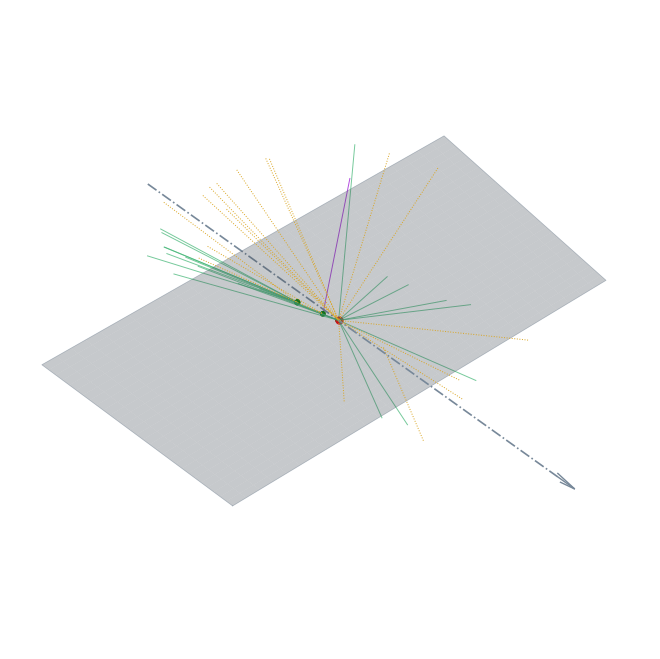

In [79]:
# B2 KS gamma event [actually not that helpful as just miss KS decay prods therefore dont see anything apart from fact obvs looks signal like]
evt_disp_maker(bb_filepath,7)

21992


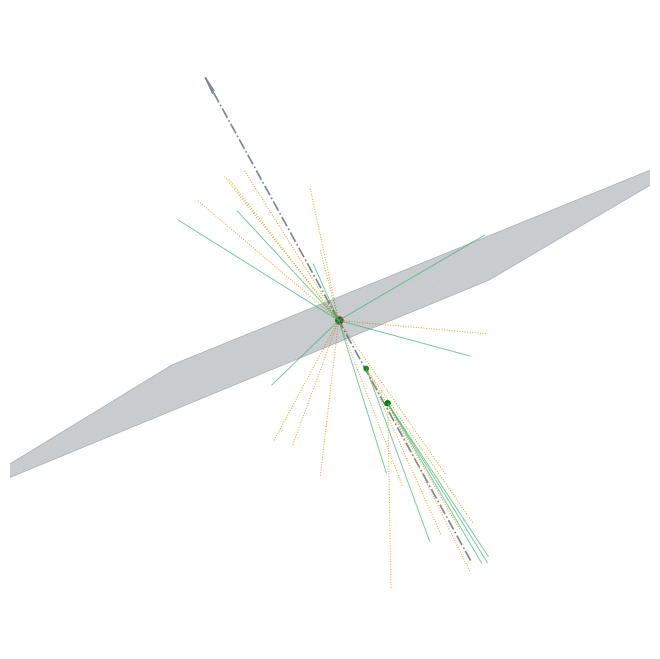

In [80]:
# funky had example - actually dosnt really show up here as hadronisation all within PV
evt_disp_maker(bb_filepath,4) #B2taunu where tau decays to e and e missed

## Plotting Thrust Pointing

In [81]:
def safe_get(event, branch, idx):
    """Return event.<branch>[idx] or None if invalid/out-of-range."""
    # get attribute
    try:
        arr = getattr(event, branch)
    except Exception:
        return None
    # scalar branch
    if not hasattr(arr, "__len__"):
        return arr
    if idx is None:
        return None
    try:
        if idx < 0 or idx >= len(arr):
            return None
    except Exception:
        return None
    try:
        return arr[idx]
    except Exception:
        return None

def calc_cos_theta(px,py,pz,p_tot,utx,uty,utz):
    cosTheta = (px*utx+py*uty+pz*utz)/p_tot
    return cosTheta

Bhadron_list = cfg.Bhadron_MC_PDG_ID 


In [82]:
def plot_q_meson_thrust_pointing(bbfile, index):
    
    expressions = [


        "MC_PDG",
        "MC_p",
        "MC_px",
        "MC_py",
        "MC_pz",
        "MC_orivtx_x",
        "MC_orivtx_y",
        "MC_orivtx_z",  
        
        "MC_M1",
        "MC_M2",
        "MC_genStatus",
        "MC_D1",
        
    ]

    expressions +=[ 'evt_id', 'MCq2_p', 'MCq2_px', 'MCq2_py', 'MCq2_pz','MCq1_p', 'MCq1_px', 'MCq1_py', 'MCq1_pz', 'EVT_unitThrust_x', 'EVT_unitThrust_y', 'EVT_unitThrust_z' ]


    event = uproot.concatenate(bbfile+':events', expressions=expressions)[index]

    print(event["evt_id"]) 

    #find parent mesons

    particles = len(event.MC_PDG)
    evt_ID  = event["evt_id"]

    unitThrust_x = safe_get(event, "EVT_unitThrust_x", 0)#event.EVT_unitThrust_x
    unitThrust_y = safe_get(event, "EVT_unitThrust_y", 0)#event.EVT_unitThrust_y
    unitThrust_z = safe_get(event, "EVT_unitThrust_z", 0)#event.EVT_unitThrust_z

    q1_px = safe_get(event, "MCq1_px",0)
    q1_py = safe_get(event, "MCq1_py",0)
    q1_pz = safe_get(event, "MCq1_pz",0)
    q1_ptot = safe_get(event, "MCq1_p",0)
    q1_cosTheta = calc_cos_theta(q1_px,q1_py,q1_pz,q1_ptot,unitThrust_x,unitThrust_y,unitThrust_z)
    q1_theta = np.arccos(q1_cosTheta)

    q2_px = safe_get(event, "MCq2_px",0)
    q2_py = safe_get(event, "MCq2_py",0)
    q2_pz = safe_get(event, "MCq2_pz",0)
    q2_ptot = safe_get(event, "MCq2_p",0)
    q2_cosTheta = calc_cos_theta(q2_px,q2_py,q2_pz,q2_ptot,unitThrust_x,unitThrust_y,unitThrust_z)
    q2_theta = np.arccos(q2_cosTheta)


    for p in range(particles):

        ID = safe_get(event, "MC_PDG", p)
        px = safe_get(event, "MC_px", p)
        py = safe_get(event, "MC_py", p)
        pz = safe_get(event, "MC_pz", p)
        p_tot = safe_get(event, "MC_p", p)


        cosTheta = calc_cos_theta(px,py,pz,p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

        if cosTheta>0: #ie. in hemisEmin

            if abs(ID) in Bhadron_list: # start with B hadron 
                print(f"hemisEmin index {p} contains ID {ID}")
                
                SS_B_indx = p
                SS_B_ID = ID
                SS_cosTheta = cosTheta
                SS_theta = np.arccos(cosTheta)

                break

    for p in range(particles):

        ID = safe_get(event, "MC_PDG", p)
        d1 = safe_get(event, "MC_D1", p) 
        d2 = safe_get(event, "MC_D2", p) 

        px = safe_get(event, "MC_px", p)
        py = safe_get(event, "MC_py", p)
        pz = safe_get(event, "MC_pz", p)
        p_tot = safe_get(event, "MC_p", p)

        cosTheta = calc_cos_theta(px,py,pz,p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

        if cosTheta<0: #ie. in hemisEmax

            if abs(ID) in Bhadron_list: # start with B hadron 
                print(f"hemisEmax index {p} contains ID {ID}")
                
                OS_B_indx = p
                OS_B_ID = ID
                OS_cosTheta = cosTheta
                OS_theta = np.arccos(cosTheta)

                break
    print(q1_theta)
    print(SS_theta)

    plt.plot(q1_theta/(2*np.pi)*360*np.ones(10), np.arange(0,10,1), label="q1")
    plt.plot(SS_theta/(2*np.pi)*360*np.ones(10), np.arange(0,10,1), label="SS_Bhad")
    plt.plot(q2_theta/(2*np.pi)*360*np.ones(10), np.arange(0,10,1), label="q2")
    plt.plot(OS_theta/(2*np.pi)*360*np.ones(10), np.arange(0,10,1), label="OS_Bhad")
    plt.legend()
    plt.xlabel("Angle from Thrust/ degrees")
    plt.xlim(0,40)
    plt.show()

    plt.plot(q1_theta/(2*np.pi)*360*np.ones(10), np.arange(0,10,1), label="q1")
    plt.plot(SS_theta/(2*np.pi)*360*np.ones(10), np.arange(0,10,1), label="SS_Bhad")
    plt.plot(q2_theta/(2*np.pi)*360*np.ones(10), np.arange(0,10,1), label="q2")
    plt.plot(OS_theta/(2*np.pi)*360*np.ones(10), np.arange(0,10,1), label="OS_Bhad")
    plt.legend()
    plt.xlabel("Angle from Thrust/ degrees")
    plt.xlim(140, 180)
    plt.show()

def return_q_meson_thrust_pointing(bbfile, index):
    
    expressions = [


        "MC_PDG",
        "MC_p",
        "MC_px",
        "MC_py",
        "MC_pz",
        "MC_orivtx_x",
        "MC_orivtx_y",
        "MC_orivtx_z",  
        
        "MC_M1",
        "MC_M2",
        "MC_genStatus",
        "MC_D1",
        
    ]

    expressions +=[ 'evt_id', 'MCq2_p', 'MCq2_px', 'MCq2_py', 'MCq2_pz','MCq1_p', 'MCq1_px', 'MCq1_py', 'MCq1_pz', 'EVT_unitThrust_x', 'EVT_unitThrust_y', 'EVT_unitThrust_z' ]


    event = uproot.concatenate(bbfile+':events', expressions=expressions)[index]

    print(event["evt_id"]) 

    #find parent mesons

    particles = len(event.MC_PDG)
    evt_ID  = event["evt_id"]

    unitThrust_x = safe_get(event, "EVT_unitThrust_x", 0)#event.EVT_unitThrust_x
    unitThrust_y = safe_get(event, "EVT_unitThrust_y", 0)#event.EVT_unitThrust_y
    unitThrust_z = safe_get(event, "EVT_unitThrust_z", 0)#event.EVT_unitThrust_z

    q1_px = safe_get(event, "MCq1_px",0)
    q1_py = safe_get(event, "MCq1_py",0)
    q1_pz = safe_get(event, "MCq1_pz",0)
    q1_ptot = safe_get(event, "MCq1_p",0)
    q1_cosTheta = calc_cos_theta(q1_px,q1_py,q1_pz,q1_ptot,unitThrust_x,unitThrust_y,unitThrust_z)
    q1_theta = np.arccos(q1_cosTheta)

    q2_px = safe_get(event, "MCq2_px",0)
    q2_py = safe_get(event, "MCq2_py",0)
    q2_pz = safe_get(event, "MCq2_pz",0)
    q2_ptot = safe_get(event, "MCq2_p",0)
    q2_cosTheta = calc_cos_theta(q2_px,q2_py,q2_pz,q2_ptot,unitThrust_x,unitThrust_y,unitThrust_z)
    q2_theta = np.arccos(q2_cosTheta)


    for p in range(particles):

        ID = safe_get(event, "MC_PDG", p)
        px = safe_get(event, "MC_px", p)
        py = safe_get(event, "MC_py", p)
        pz = safe_get(event, "MC_pz", p)
        p_tot = safe_get(event, "MC_p", p)


        cosTheta = calc_cos_theta(px,py,pz,p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

        if cosTheta>0: #ie. in hemisEmin

            if abs(ID) in Bhadron_list: # start with B hadron 
                print(f"hemisEmin index {p} contains ID {ID}")
                
                SS_B_indx = p
                SS_B_ID = ID
                SS_cosTheta = cosTheta
                SS_theta = np.arccos(cosTheta)

                break

    for p in range(particles):

        ID = safe_get(event, "MC_PDG", p)
        d1 = safe_get(event, "MC_D1", p) 
        d2 = safe_get(event, "MC_D2", p) 

        px = safe_get(event, "MC_px", p)
        py = safe_get(event, "MC_py", p)
        pz = safe_get(event, "MC_pz", p)
        p_tot = safe_get(event, "MC_p", p)

        cosTheta = calc_cos_theta(px,py,pz,p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

        if cosTheta<0: #ie. in hemisEmax

            if abs(ID) in Bhadron_list: # start with B hadron 
                print(f"hemisEmax index {p} contains ID {ID}")
                
                OS_B_indx = p
                OS_B_ID = ID
                OS_cosTheta = cosTheta
                OS_theta = np.arccos(cosTheta)

                break

    return q1_theta, q2_theta, SS_theta, OS_theta

6756
hemisEmin index 52 contains ID -513.0
hemisEmax index 47 contains ID 513.0
0.17903431
0.07267644


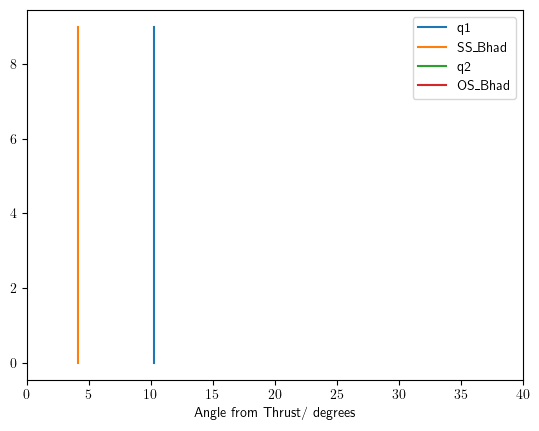

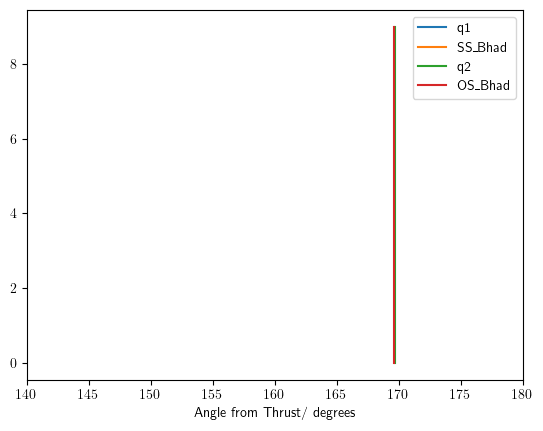

In [83]:
plot_q_meson_thrust_pointing(bb_filepath,7) #funkyhad = flase

15730
hemisEmin index 20 contains ID -533.0
hemisEmax index 29 contains ID 523.0
0.011611513
0.008141298


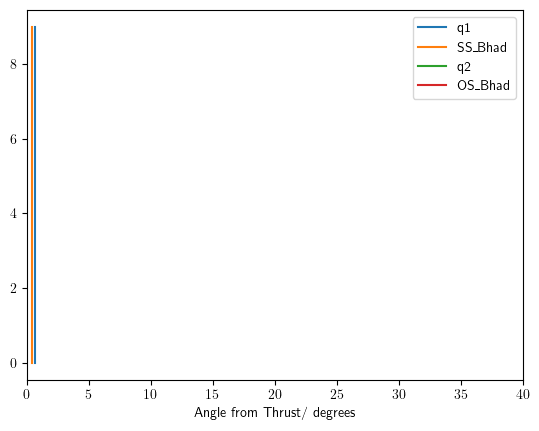

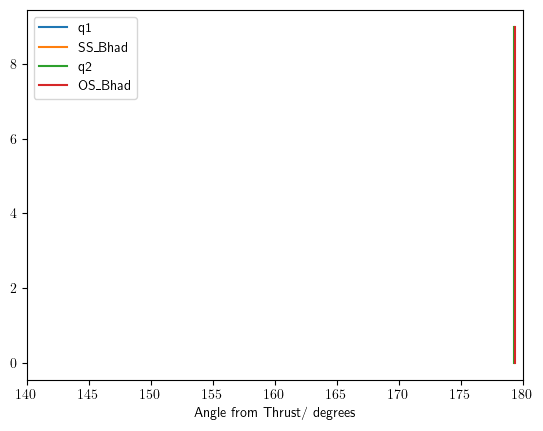

In [84]:
plot_q_meson_thrust_pointing(bb_filepath,43) #funky had = false

16709
hemisEmin index 24 contains ID 523.0
hemisEmax index 16 contains ID -511.0
3.1109364
0.028774392


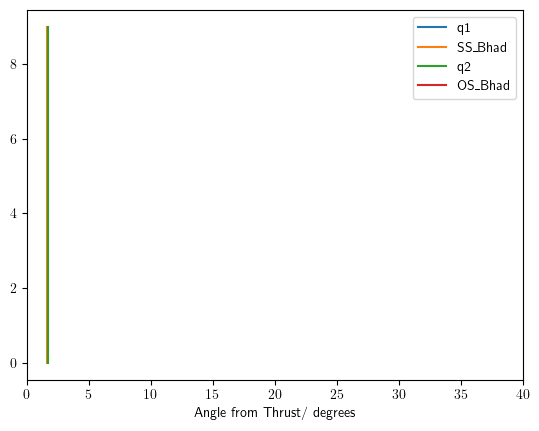

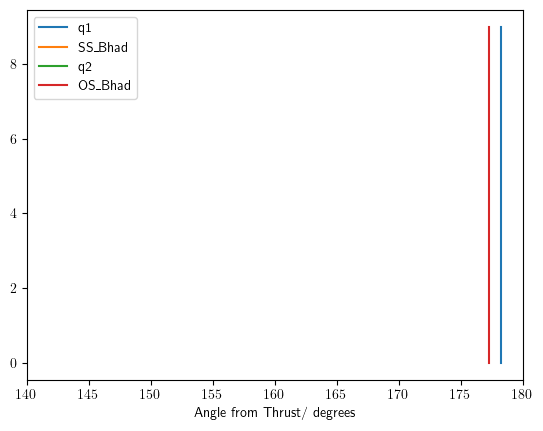

In [85]:
plot_q_meson_thrust_pointing(bb_filepath,14) #funky had = true

22170
hemisEmin index 51 contains ID -523.0
hemisEmax index 65 contains ID -3122.0
0.09154269
0.23304038


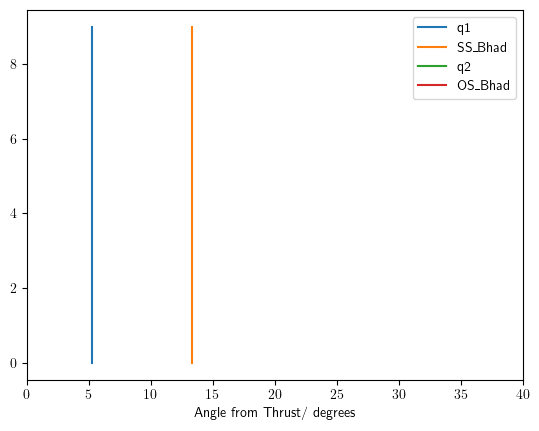

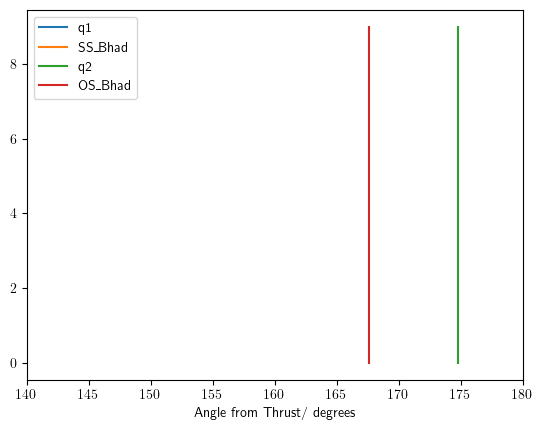

In [86]:
plot_q_meson_thrust_pointing(bb_filepath,0) #funky had = true

27850
hemisEmin index 19 contains ID -513.0
hemisEmax index 28 contains ID 521.0
0.030039357
0.021070164


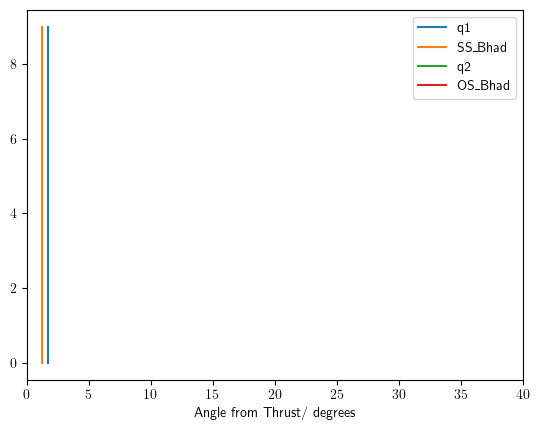

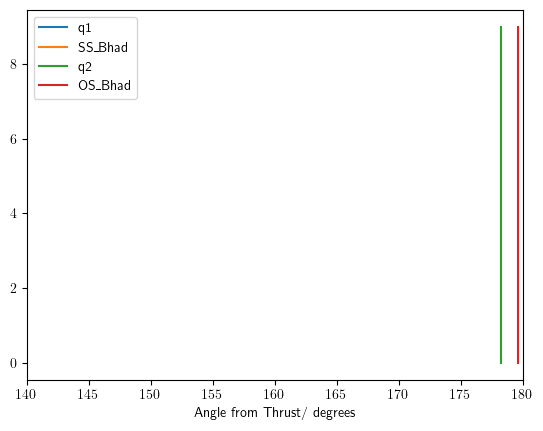

In [87]:
plot_q_meson_thrust_pointing(bb_filepath,51) #funky had = true

### Conclude we can't tell the difference bewteen "funky had" and not based on pointing. Therefore probably just in parenting in hadronisation with minimal kinematic effect. Therefore ignore as shouldn't have an impact on our analysis - but check with histogram anyway

In [92]:
event_numbers = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82]
funkyhad = [True,True,True,True,True,True,False,False,True,False,True,False,True,False,True,True,False,True,False,True,False,False,True,True,True,True,True,False,False,True,False,True,True,False,True,False,False,True,True,True,True,True,True,False,True,False,True,False,True,False,False,True,True,False,True,True,False,True,True,True,True,True,True,True,True,True,False,True,False,False,True,False,False,False,True,True,False,False,True,True,True,True,True]

In [93]:
funky_had_dict = {"q1_theta":[], "q2_theta":[],"SS_theta":[],"OS_theta":[]}
normal_had_dict = {"q1_theta":[], "q2_theta":[],"SS_theta":[],"OS_theta":[]}

for i in range(len(event_numbers)):
    q1_theta, q2_theta, SS_theta, OS_theta = return_q_meson_thrust_pointing(bb_filepath,event_numbers[i])

    if funkyhad[i] ==True:
        funky_had_dict["q1_theta"].append(q1_theta)
        funky_had_dict["q2_theta"].append(q2_theta)
        funky_had_dict["SS_theta"].append(SS_theta)
        funky_had_dict["OS_theta"].append(OS_theta)

    elif funkyhad[i] ==False:
        normal_had_dict["q1_theta"].append(q1_theta)
        normal_had_dict["q2_theta"].append(q2_theta)
        normal_had_dict["SS_theta"].append(SS_theta)
        normal_had_dict["OS_theta"].append(OS_theta)

    else:
        raise ValueError("funkhad must be true or flase")

22170
hemisEmin index 51 contains ID -523.0
hemisEmax index 65 contains ID -3122.0
5726
hemisEmin index 9 contains ID -513.0
hemisEmax index 20 contains ID -5224.0
28069
hemisEmin index 18 contains ID 513.0
hemisEmax index 9 contains ID -511.0
11891
hemisEmin index 44 contains ID 523.0
hemisEmax index 36 contains ID -513.0
21992
hemisEmin index 39 contains ID -523.0
hemisEmax index 48 contains ID 533.0
20012
hemisEmin index 19 contains ID -523.0
hemisEmax index 26 contains ID 523.0
2762
hemisEmin index 49 contains ID -5122.0
hemisEmax index 32 contains ID 5222.0
6756
hemisEmin index 52 contains ID -513.0
hemisEmax index 47 contains ID 513.0
4244
hemisEmin index 27 contains ID -511.0
hemisEmax index 35 contains ID 523.0
19104
hemisEmin index 44 contains ID -511.0
hemisEmax index 37 contains ID 523.0
5813
hemisEmin index 39 contains ID 513.0
hemisEmax index 32 contains ID -521.0
6242
hemisEmin index 54 contains ID 511.0
hemisEmax index 38 contains ID -523.0
26583
hemisEmin index 39 conta

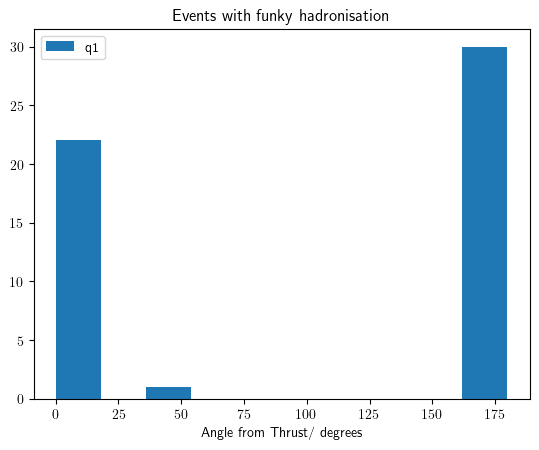

In [98]:
plt.hist([i*360/(2*np.pi)for i in funky_had_dict["q1_theta"]], label="q1")
plt.xlabel("Angle from Thrust/ degrees")
plt.title("Events with funky hadronisation")
plt.legend()
plt.show()

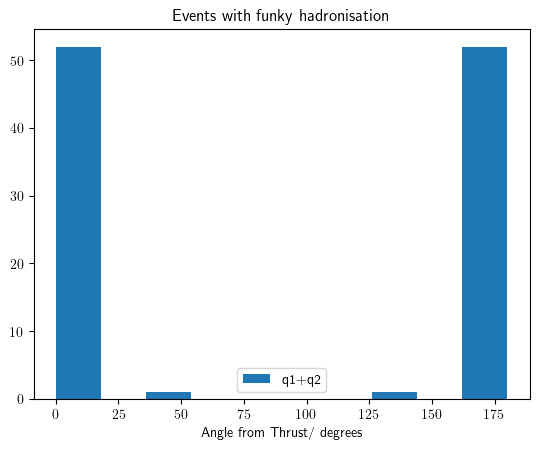

In [100]:
plt.hist([i*360/(2*np.pi)for i in funky_had_dict["q2_theta"]]+[i*360/(2*np.pi)for i in funky_had_dict["q1_theta"]], label="q1+q2")
plt.xlabel("Angle from Thrust/ degrees")
plt.title("Events with funky hadronisation")
plt.legend()
plt.show()

#perfectly symmetric as expect

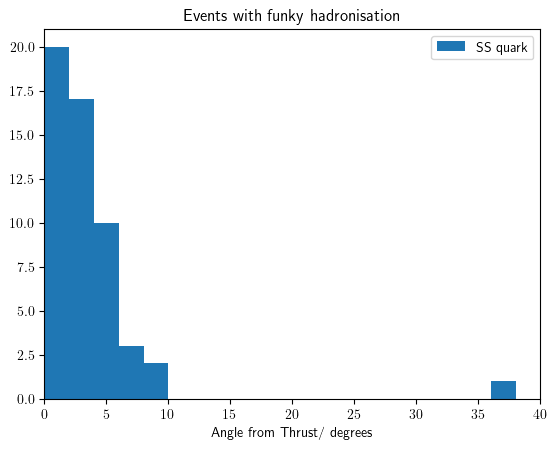

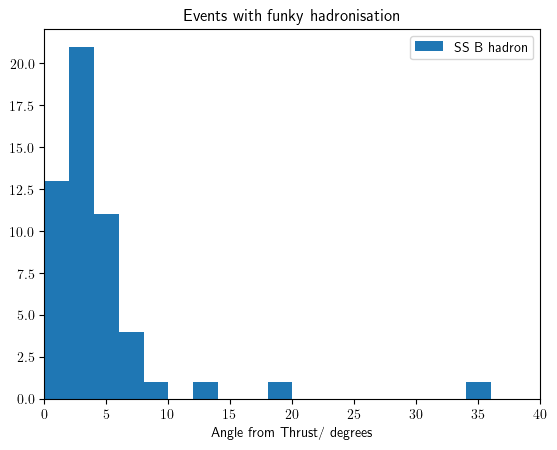

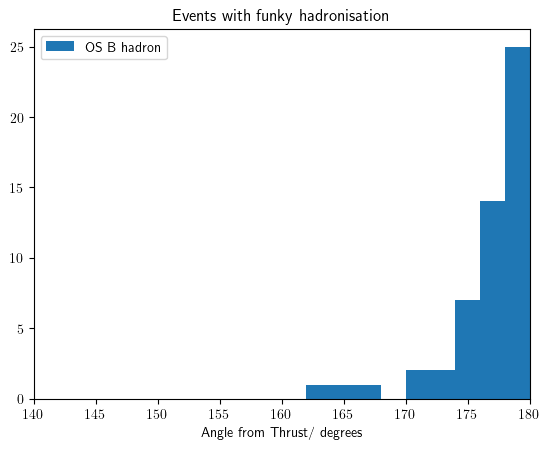

In [121]:
plt.hist([i*360/(2*np.pi)for i in funky_had_dict["q2_theta"]]+[i*360/(2*np.pi)for i in funky_had_dict["q1_theta"]], label="SS quark", bins=20,range = (0,40))
plt.xlabel("Angle from Thrust/ degrees")
plt.title("Events with funky hadronisation")
plt.legend()
plt.xlim(0,40)
plt.show()

plt.hist([i*360/(2*np.pi)for i in funky_had_dict["SS_theta"]], label="SS B hadron", bins=20, range=(0,40))
plt.xlabel("Angle from Thrust/ degrees")
plt.title("Events with funky hadronisation")
plt.legend()
plt.xlim(0,40)
plt.show()

plt.hist([i*360/(2*np.pi)for i in funky_had_dict["OS_theta"]], label="OS B hadron", bins=20, range=(140,180))
plt.xlabel("Angle from Thrust/ degrees")
plt.title("Events with funky hadronisation")
plt.legend()
plt.xlim(140,180)
plt.show()

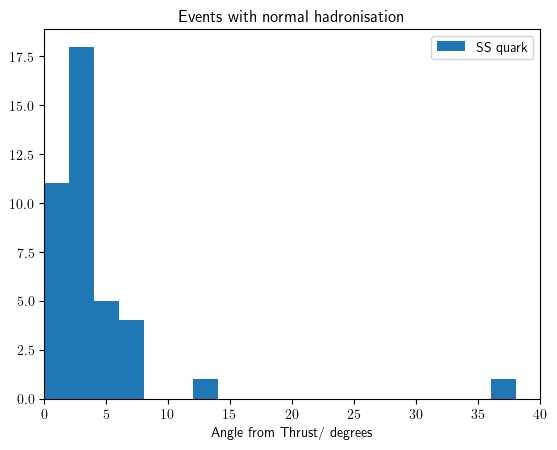

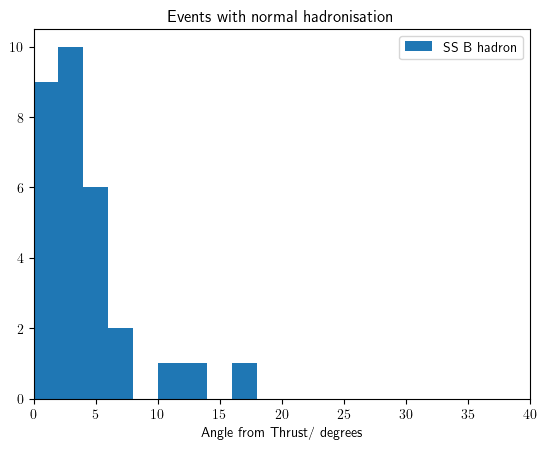

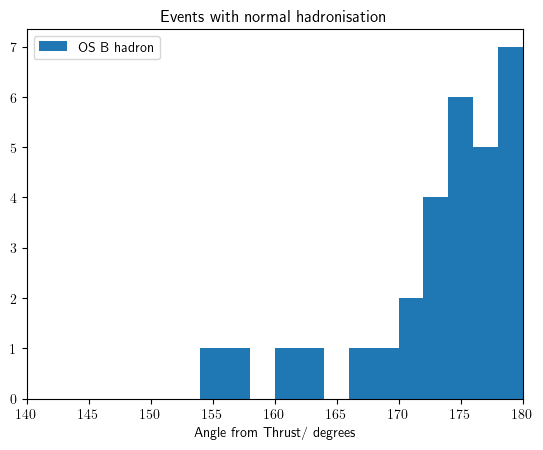

In [122]:
plt.hist([i*360/(2*np.pi)for i in normal_had_dict["q2_theta"]]+[i*360/(2*np.pi)for i in funky_had_dict["q1_theta"]], label="SS quark", bins=20,range = (0,40))
plt.xlabel("Angle from Thrust/ degrees")
plt.title("Events with normal hadronisation")
plt.legend()
plt.xlim(0,40)
plt.show()

plt.hist([i*360/(2*np.pi)for i in normal_had_dict["SS_theta"]], label="SS B hadron", bins=20, range=(0,40))
plt.xlabel("Angle from Thrust/ degrees")
plt.title("Events with normal hadronisation")
plt.legend()
plt.xlim(0,40)
plt.show()

plt.hist([i*360/(2*np.pi)for i in normal_had_dict["OS_theta"]], label="OS B hadron", bins=20, range=(140,180))
plt.xlabel("Angle from Thrust/ degrees")
plt.title("Events with normal hadronisation")
plt.legend()
plt.xlim(140,180)
plt.show()

Such low stats actually useless - but all within reasonable region

## Comparison of tau -> pi nu and tau -> pi nu pi0 events

### tau to pi nu pi0


11891


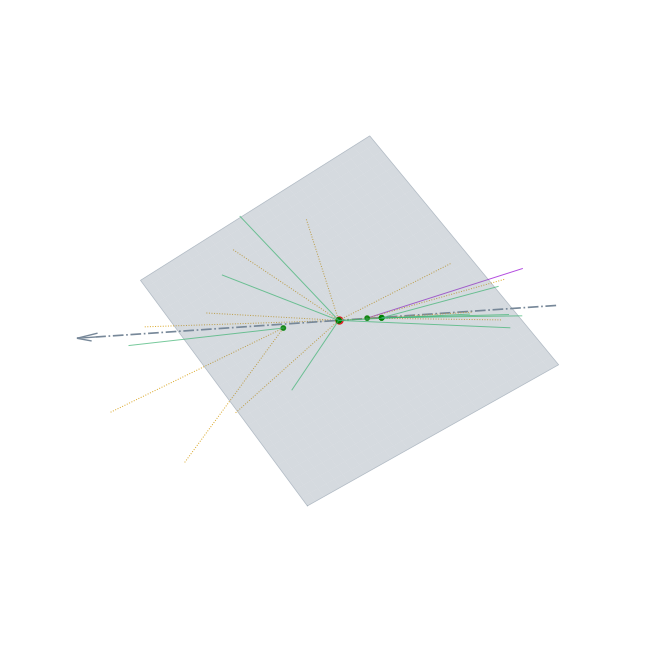

12207


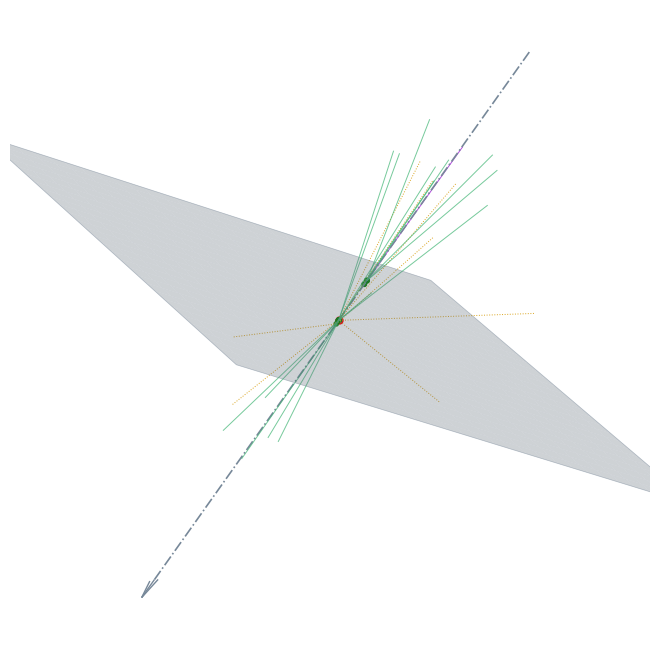

16556


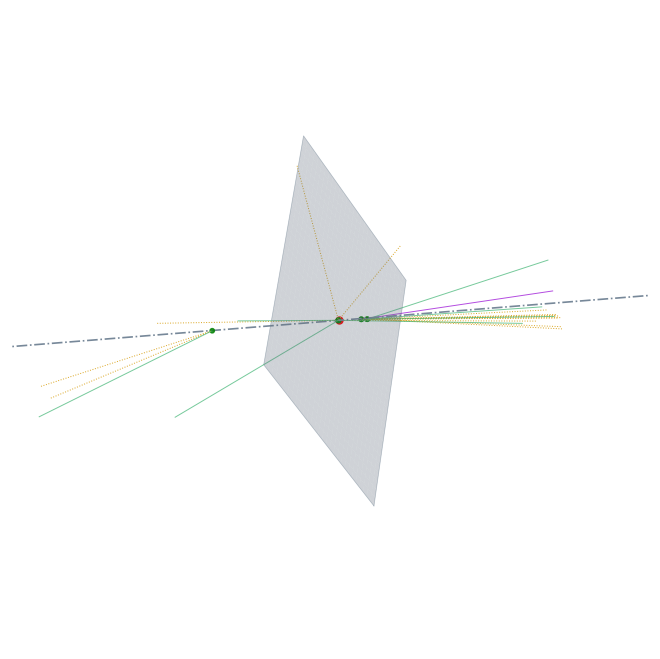

24161


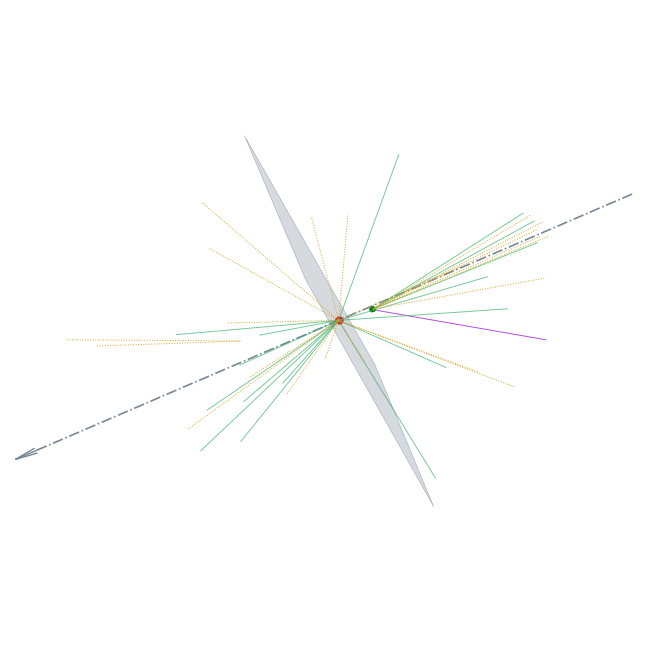

In [5]:
evt_disp_maker(bb_filepath,3) 
evt_disp_maker(bb_filepath,25) 
evt_disp_maker(bb_filepath,59) 
evt_disp_maker(bb_filepath,70) 

16709


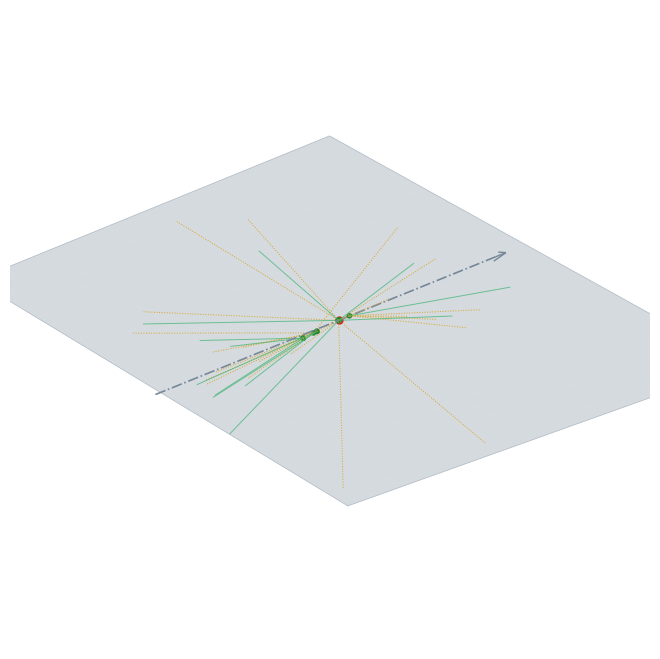

In [6]:
evt_disp_maker(bb_filepath,14) 

### tau to pi nu

22170


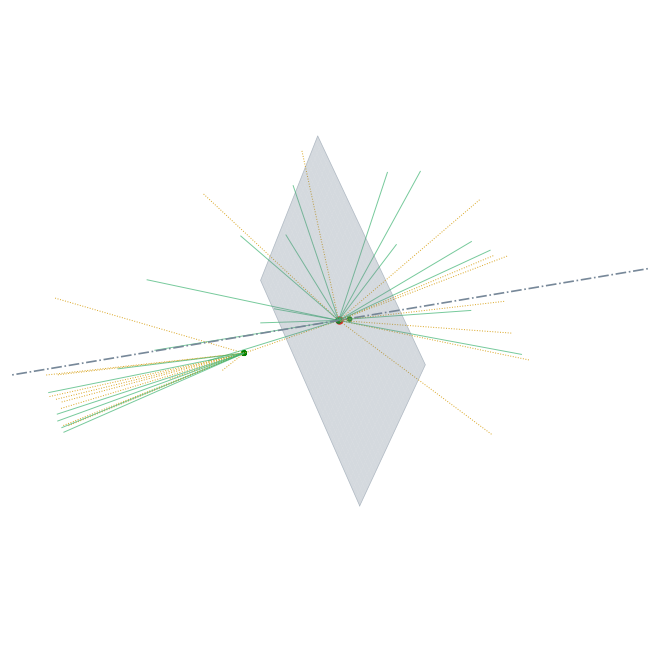

3654


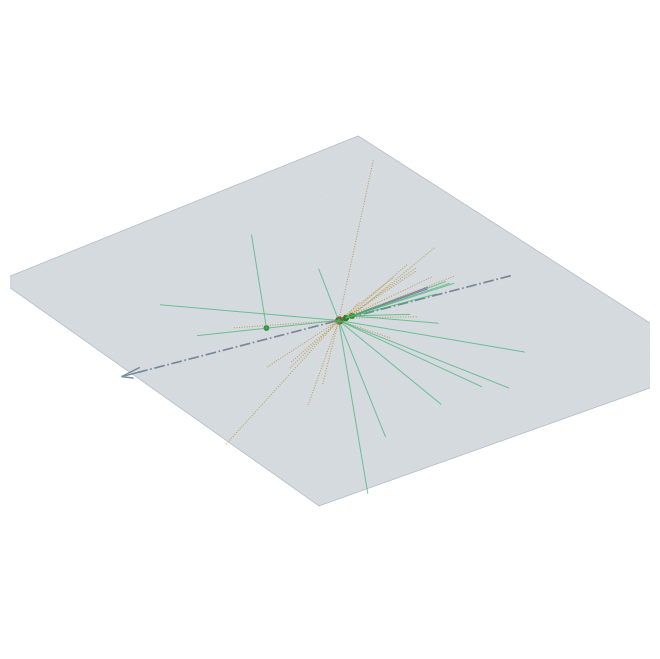

7908


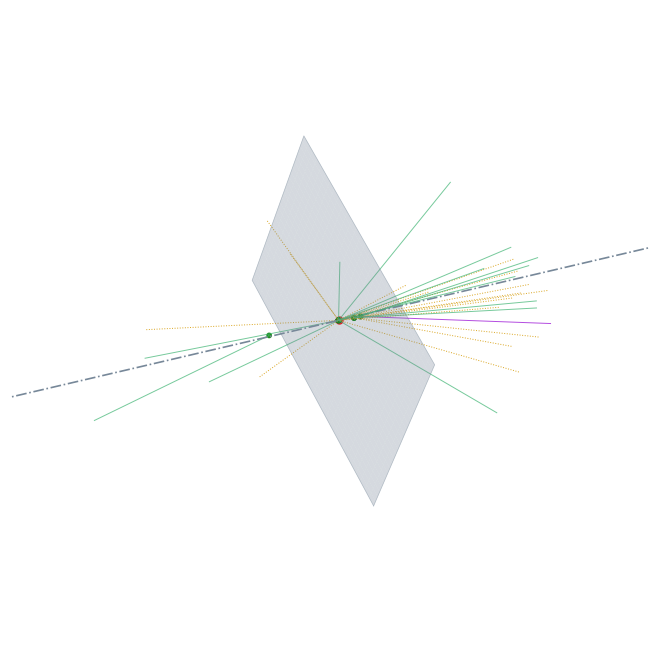

24549


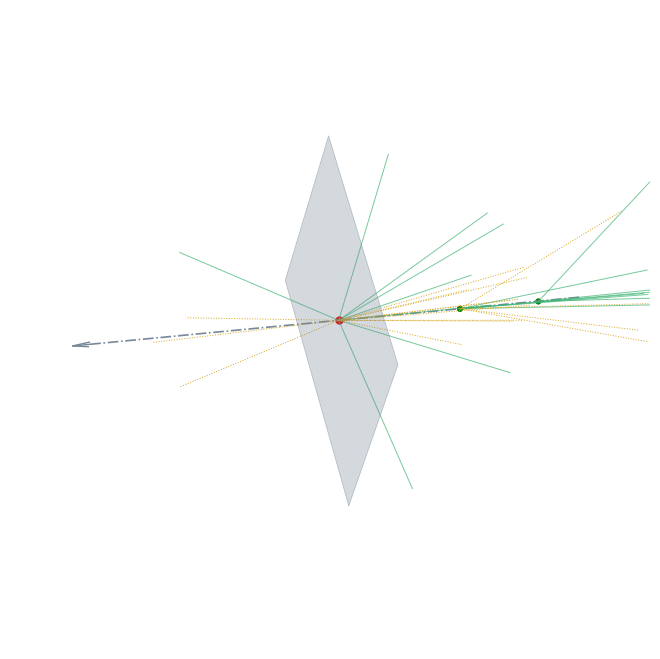

In [7]:
evt_disp_maker(bb_filepath,0) 
evt_disp_maker(bb_filepath,20) 
evt_disp_maker(bb_filepath,68) 
evt_disp_maker(bb_filepath,73) 